# Problem Statement

## **Business Context**

Vehicle breakdowns and engine failures lead to significant financial losses for both individual owners and fleet operators. Unexpected engine failures can cause expensive repairs, operational downtime, and safety risks. Predictive maintenance in the automotive industry can help minimize these issues by leveraging sensor data to forecast potential failures before they occur. 

Automobile manufacturers, fleet managers, and service providers aim to develop data-driven solutions to improve engine reliability and optimize maintenance schedules. By analyzing engine health parameters such as RPM, temperature, pressure, and other sensor readings, machine learning models can be trained to predict when an engine requires maintenance, allowing proactive intervention before a failure occurs. 

The sensor values in the dataset are consistent with the operating parameters of larger and small engines commonly found in equipment like Vechiles, lawnmowers, portable generators, and compact machinery. Some engines operate at lower RPMs, pressures, and temperatures compared to larger automotive engines and vice versa. Therefore, the data is appropriate for developing predictive maintenance models tailored to large and small engine applications. 


## **Objective**

As a Data Scientist, your goal is to build a predictive maintenance model that can analyze historical and real-time engine sensor data to identify potential failures. The model should accurately classify whether an engine requires maintenance or is operating normally. 

This solution will help:

Reduce unplanned breakdowns and costly repairs.
Improve vehicle performance and engine lifespan.
Optimize maintenance schedules to minimize downtime
Provide data-driven insights to manufacturers and fleet operators for better decision-making. 

## **Data Description**

- **Engine_RPM:** The number of revolutions per minute (RPM) of the engine, indicating engine speed. It is defined in Revolutions per Minute (RPM). 
- **Lub_Oil_Pressure:** The pressure of the lubricating oil in the engine, essential for reducing friction and wear. It is defined in bar or kilopascals (kPa) 
- **Fuel_Pressure:** The pressure at which fuel is supplied to the engine, critical for proper combustion. It is defined in bar or kilopascals (kPa) 
- **Coolant_Pressure:** The pressure of the engine coolant, affecting engine temperature regulation. It is defined in bar or kilopascals (kPa) 
- **Lub_Oil_Temperature:** The temperature of the lubricating oil, which impacts viscosity and engine performance. It is defined in degrees Celsius (°C) 
- **Coolant_Temperature:** The temperature of the engine coolant, crucial for preventing overheating. It is defined in degrees Celsius (°C) 
- **Engine_Condition:** A categorical or numerical label representing the health of the engine, potentially indicating normal operation or various levels of wear and failure risks. It is defined as a categorical variable (0/1) representing a state such as "0 = Off/False/Active" and "1 = On/True/Faulty"



# Model Building

In [1]:
# Create a master folder to keep all files created when executing the below code cells
import os
os.makedirs("predictive_maintenance_vehicle", exist_ok=True)

In [2]:
import os
from pathlib import Path

hf_token_path = Path(".venv/.hf_token")
if not os.environ.get("HF_TOKEN") and hf_token_path.exists():
    os.environ["HF_TOKEN"] = hf_token_path.read_text().strip()

if os.environ.get("HF_TOKEN"):
    print("HF_TOKEN found in environment.")
else:
    raise ValueError("HF_TOKEN is not set. Activate .venv or create .venv/.hf_token.")


HF_TOKEN found in environment.


In [3]:
# Create a folder for storing the model building files
os.makedirs("predictive_maintenance_vehicle/model_building", exist_ok=True)

###  Criteria 1
### Data Registration

- Create a master folder and create a subfolder "data"
- Register the data on the Hugging Face dataset space

In [4]:
os.makedirs("predictive_maintenance_vehicle/data", exist_ok=True)

#### Once the data folder created after executing the above cell - uploaded the engine_data.csv file in to the folder



In [5]:
%%writefile predictive_maintenance_vehicle/model_building/data_register.py

from huggingface_hub import HfApi
from huggingface_hub.errors import RepositoryNotFoundError

HF_TOKEN = os.getenv("HF_TOKEN")
if not HF_TOKEN:
    raise ValueError("HF_TOKEN is not set")

repo_id = "nikhileshmehta1989/Predictive_Maintenance_Vehicle"
repo_type = "dataset"

api = HfApi(token=HF_TOKEN)

print("Authenticated HF user:", api.whoami())

try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Dataset repo '{repo_id}' already exists.")
except RepositoryNotFoundError:
    print(f"Dataset repo '{repo_id}' not found. Creating it...")
    api.create_repo(
        repo_id=repo_id,
        repo_type=repo_type,
        private=False,
        exist_ok=True,
    )
    print(f"Dataset repo '{repo_id}' created.")

# Upload raw/source dataset folder contents
api.upload_folder(
    folder_path="predictive_maintenance_vehicle/data",
    repo_id=repo_id,
    repo_type=repo_type,
)

print("Folder uploaded successfully.")

Writing predictive_maintenance_vehicle/model_building/data_register.py


- Created the data/ subfolder inside predictive_maintenance_vehicle where the raw dataset and processed train/test splits will be stored. 
- Defined the Huggingface repo

###  Criteria 2
### Exploratory Data Analysis

- Data collection and background
- Data overview
- Univariate analysis
- Bivariate analysis
- Multivariate analysis
- Insights/observations based on EDA

Data source: predictive_maintenance_vehicle/data/engine_data.csv

First 5 rows:


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,Engine Condition
0,700,2.493592,11.790927,3.178981,84.144163,81.632187,1
1,876,2.941606,16.193866,2.464504,77.640934,82.445724,0
2,520,2.961746,6.553147,1.064347,77.752266,79.645777,1
3,473,3.707835,19.510172,3.727455,74.129907,71.774629,1
4,619,5.672919,15.738871,2.052251,78.396989,87.000225,0



Dataset shape: (19535, 7)

Data types:
engine_rpm            int64
lub_oil_pressure    float64
fuel_pressure       float64
coolant_pressure    float64
lub_oil_temp        float64
coolant_temp        float64
engine_condition      int64
dtype: object

Missing value summary:


,column,missing_count,missing_percent
0,engine_rpm,0,0.0
1,lub_oil_pressure,0,0.0
2,fuel_pressure,0,0.0
3,coolant_pressure,0,0.0
4,lub_oil_temp,0,0.0
5,coolant_temp,0,0.0
6,engine_condition,0,0.0


Duplicate rows: 0

Target distribution:


,class,count,percent
0,0,7218,36.95
1,1,12317,63.05


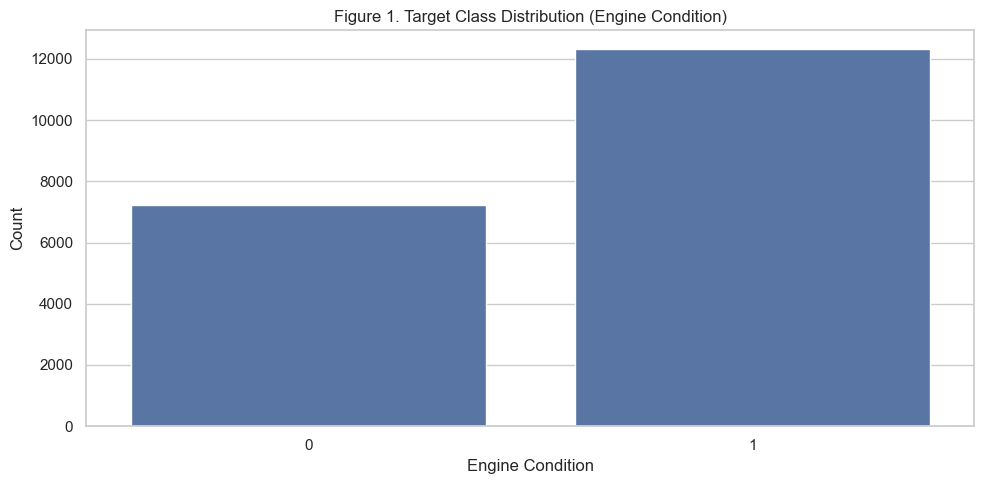


Univariate summary statistics for numeric variables:


,mean,std,min,25%,50%,75%,max
engine_rpm,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2239.000000
lub_oil_pressure,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566
fuel_pressure,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,21.138326
coolant_pressure,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505
lub_oil_temp,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,89.580796
coolant_temp,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,195.527912


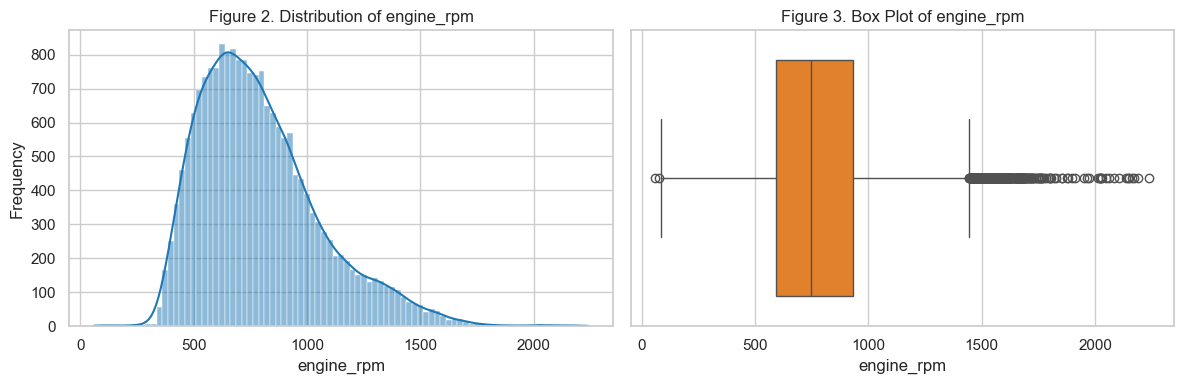

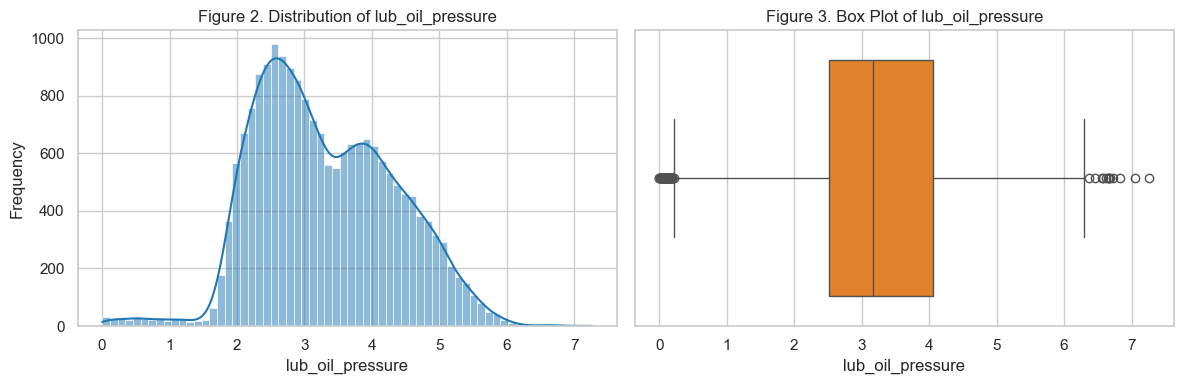

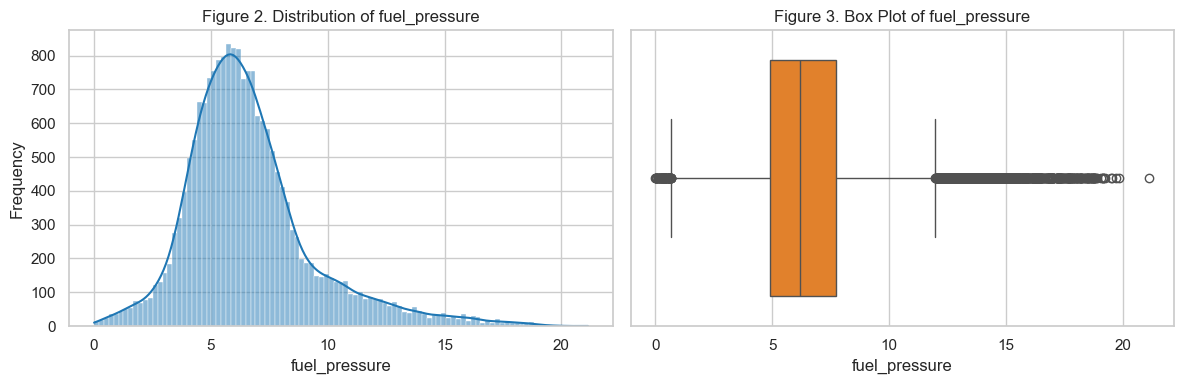

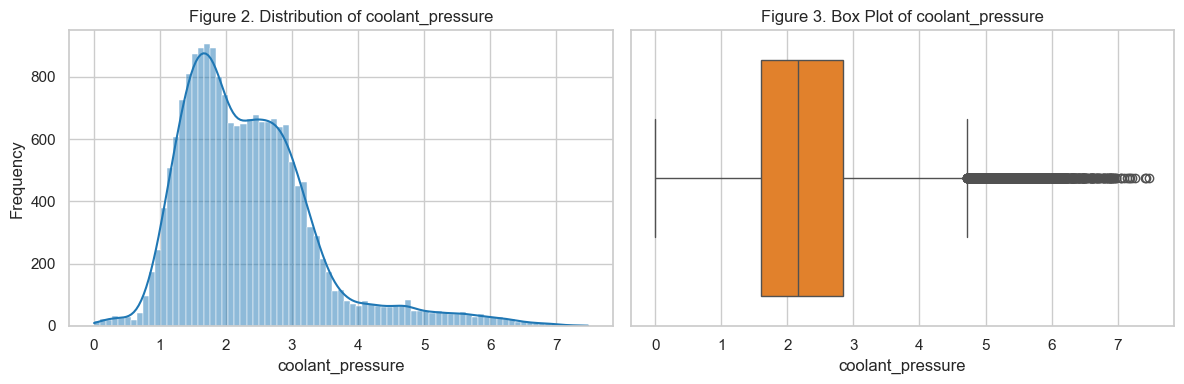

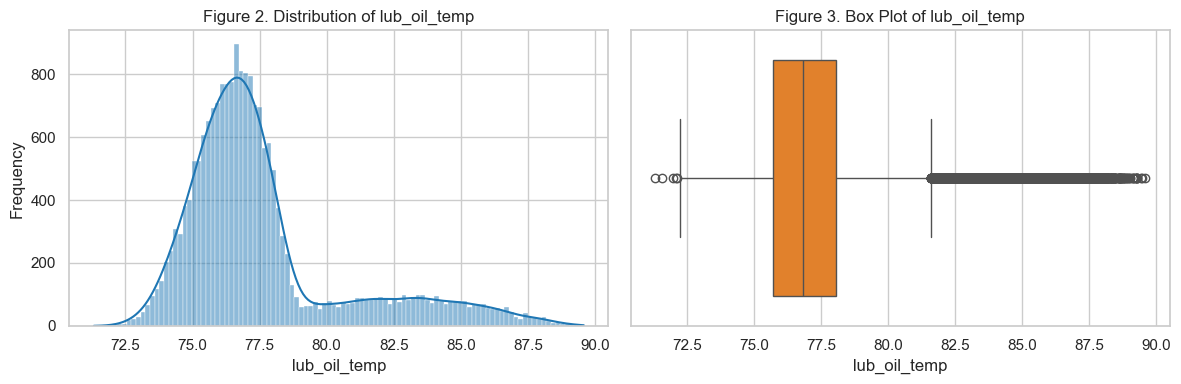

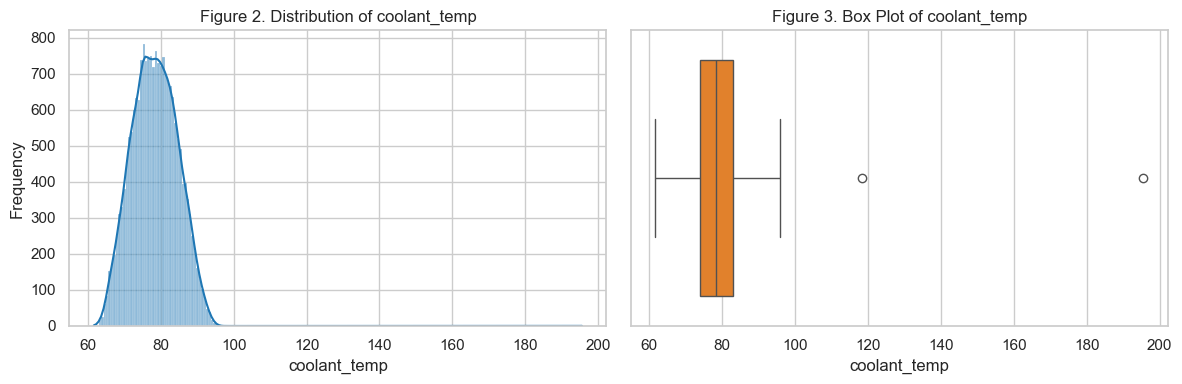

/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_df, x=target_col, y=col, ax=axes[1], palette="Set1")


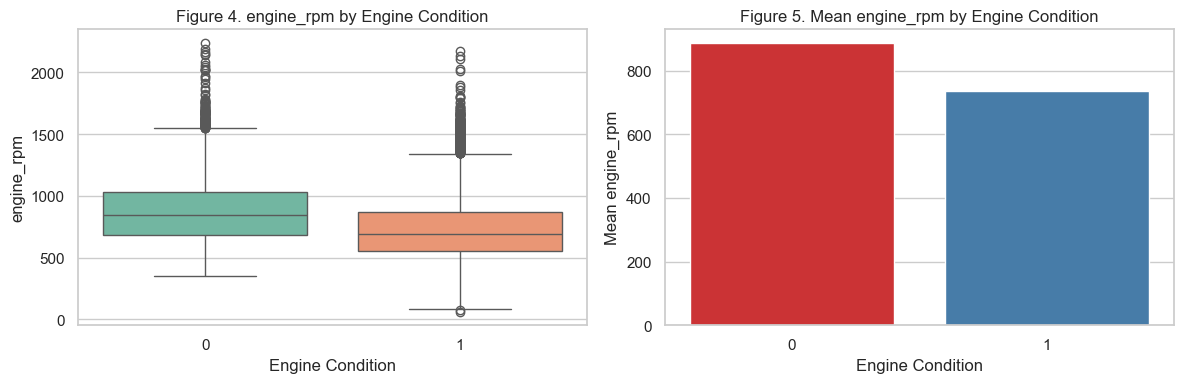

/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_df, x=target_col, y=col, ax=axes[1], palette="Set1")


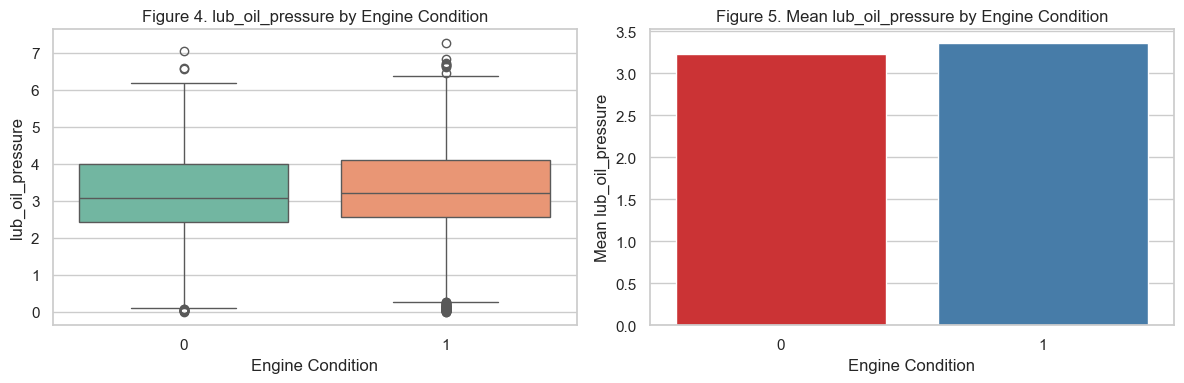

/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_df, x=target_col, y=col, ax=axes[1], palette="Set1")


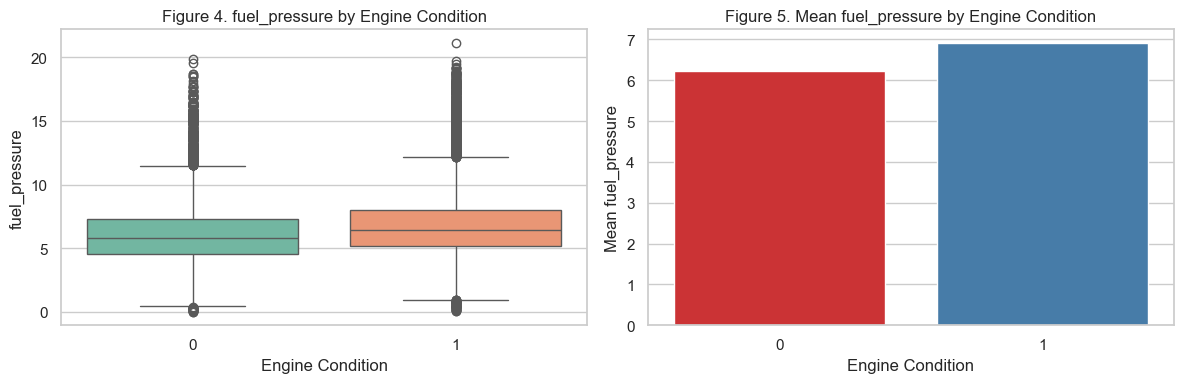

/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_df, x=target_col, y=col, ax=axes[1], palette="Set1")


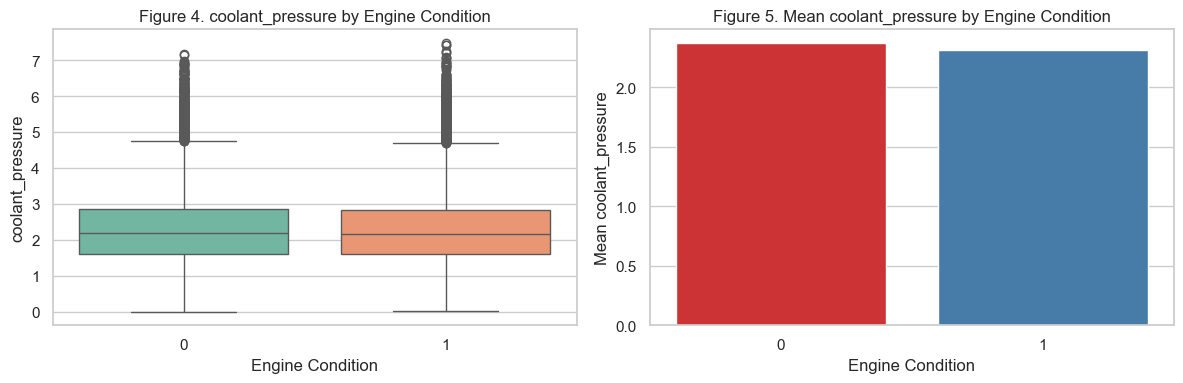

/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_df, x=target_col, y=col, ax=axes[1], palette="Set1")


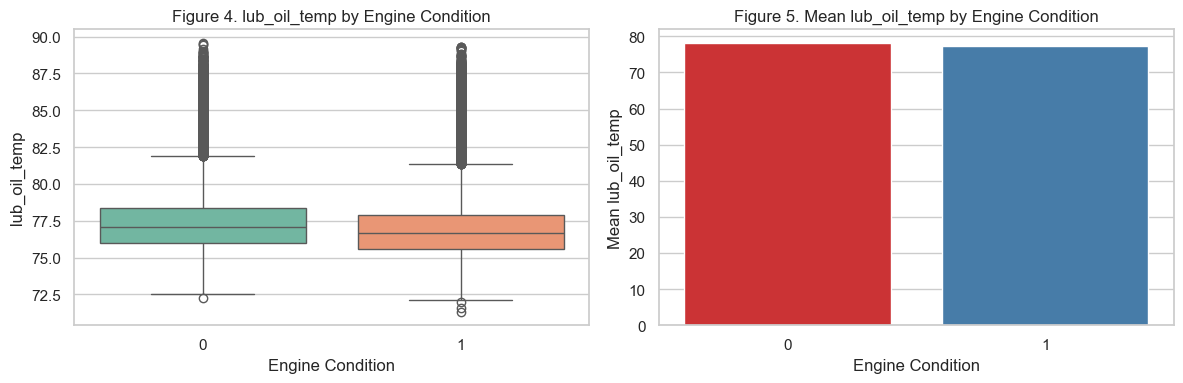

/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
/var/folders/b6/fntdmfdx13l9wwg2szdc29r40000gn/T/ipykernel_88321/308066466.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_df, x=target_col, y=col, ax=axes[1], palette="Set1")


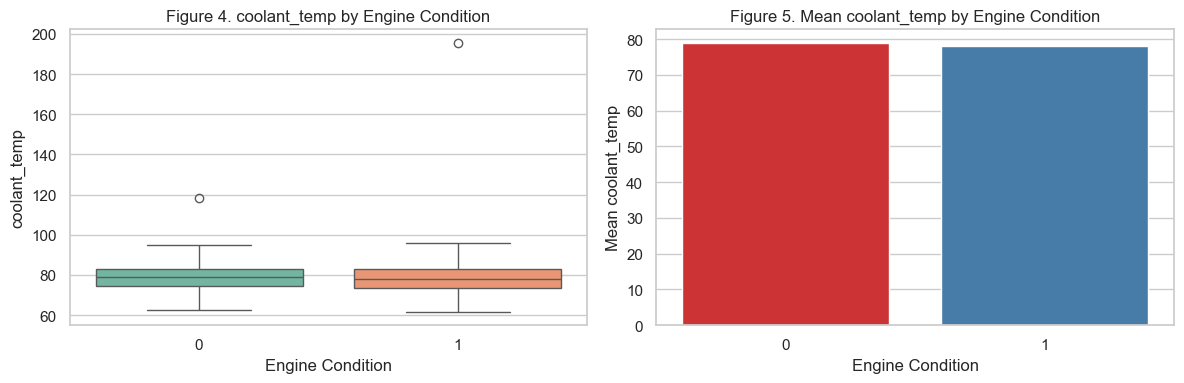

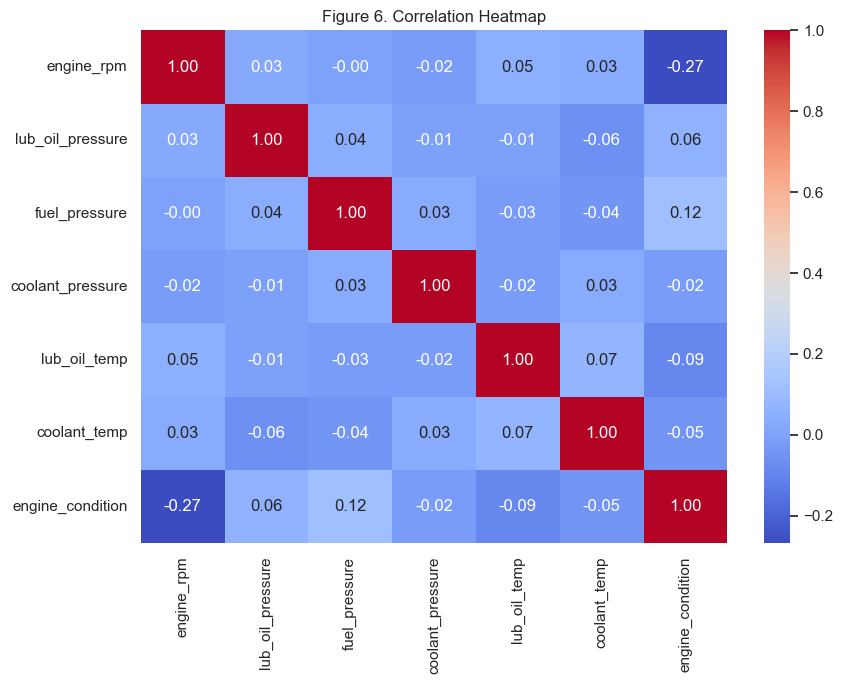

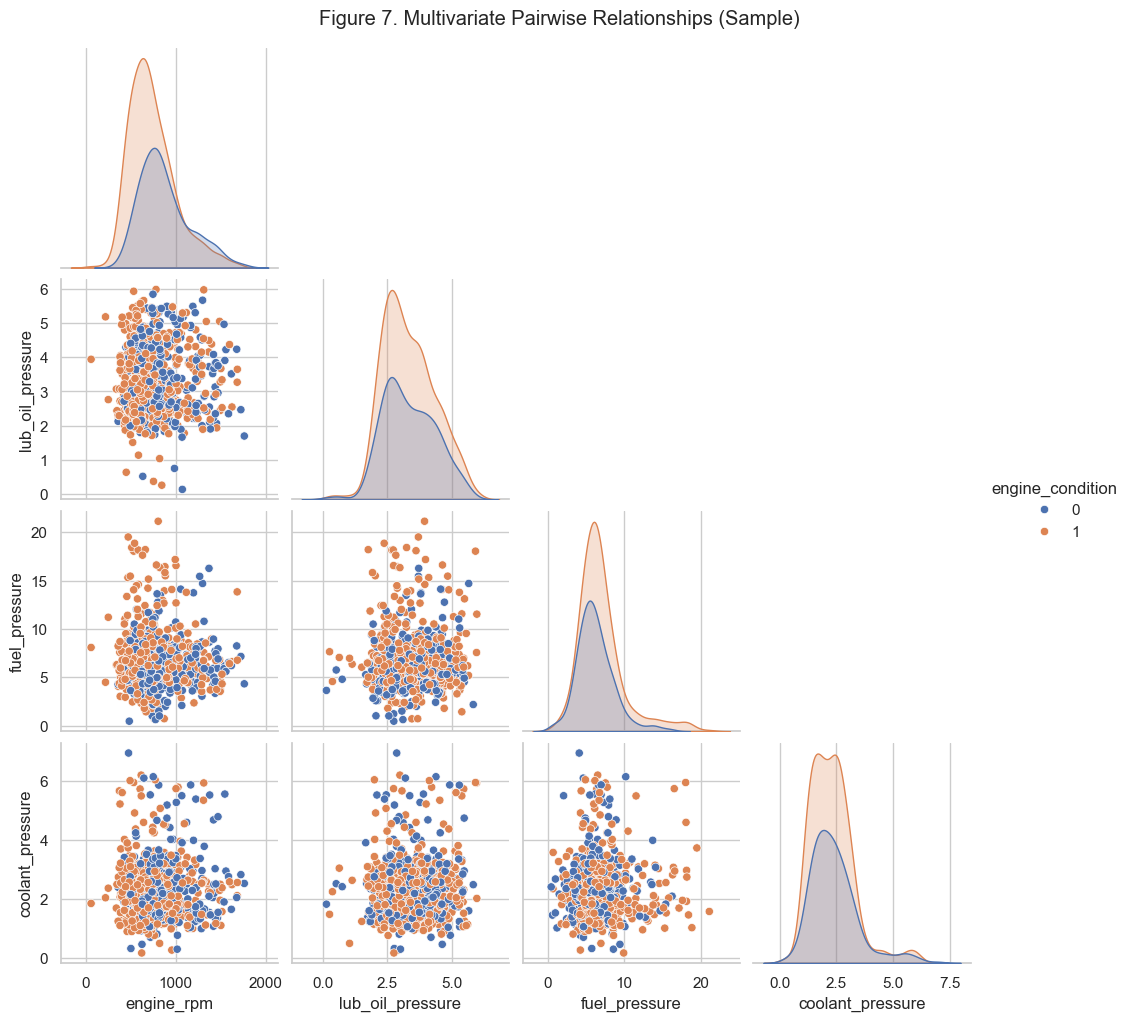


=== EDA Insights ===
1. Dataset contains 19,535 records and 7 variables (including target).
2. Target class balance: {0: 7218, 1: 12317} (percent: {0: 36.95, 1: 63.05}).
3. Missing values are low/handled according to summary table above.
4. Top positive correlations with engine_condition:
fuel_pressure       0.116
lub_oil_pressure    0.061
coolant_pressure   -0.024
5. Top negative correlations with engine_condition:
coolant_temp   -0.046
lub_oil_temp   -0.094
engine_rpm     -0.268
6. Bivariate plots indicate which sensor ranges differ most by engine condition.
7. Correlation and pairwise structure support using non-linear models in Criteria 3.


In [7]:
# Exploratory Data Analysis (EDA)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# 1) Data collection and background
local_data_path = "predictive_maintenance_vehicle/data/engine_data.csv"
if not os.path.exists(local_data_path):
    raise FileNotFoundError(f"Data file not found at {local_data_path}. Upload/copy engine_data.csv first.")

df = pd.read_csv(local_data_path)
print("Data source:", local_data_path)
print("\nFirst 5 rows:")
display(df.head())

# Standardize columns for easier analysis
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
target_col = "engine_condition"
feature_cols = [c for c in df.columns if c != target_col]

# 2) Data overview
print("\nDataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)

missing_df = df.isna().sum().reset_index()
missing_df.columns = ["column", "missing_count"]
missing_df["missing_percent"] = (missing_df["missing_count"] / len(df) * 100).round(2)
print("\nMissing value summary:")
display(missing_df)

duplicates = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicates}")

class_dist = df[target_col].value_counts().sort_index()
class_pct = (class_dist / len(df) * 100).round(2)
overview_table = pd.DataFrame({
    "class": class_dist.index,
    "count": class_dist.values,
    "percent": class_pct.values
})
print("\nTarget distribution:")
display(overview_table)

fig, ax = plt.subplots()
sns.countplot(data=df, x=target_col, ax=ax)
ax.set_title("Figure 1. Target Class Distribution (Engine Condition)")
ax.set_xlabel("Engine Condition")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# 3) Univariate analysis
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

if num_cols:
    univar_stats = df[num_cols].describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    print("\nUnivariate summary statistics for numeric variables:")
    display(univar_stats)

    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(df[col], kde=True, ax=axes[0], color="#1f77b4")
        axes[0].set_title(f"Figure 2. Distribution of {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frequency")

        sns.boxplot(x=df[col], ax=axes[1], color="#ff7f0e")
        axes[1].set_title(f"Figure 3. Box Plot of {col}")
        axes[1].set_xlabel(col)

        plt.tight_layout()
        plt.show()

# 4) Bivariate analysis
if num_cols:
    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        sns.boxplot(data=df, x=target_col, y=col, ax=axes[0], palette="Set2")
        axes[0].set_title(f"Figure 4. {col} by Engine Condition")
        axes[0].set_xlabel("Engine Condition")
        axes[0].set_ylabel(col)

        mean_df = df.groupby(target_col, as_index=False)[col].mean()
        sns.barplot(data=mean_df, x=target_col, y=col, ax=axes[1], palette="Set1")
        axes[1].set_title(f"Figure 5. Mean {col} by Engine Condition")
        axes[1].set_xlabel("Engine Condition")
        axes[1].set_ylabel(f"Mean {col}")

        plt.tight_layout()
        plt.show()

# 5) Multivariate analysis
corr_df = df.select_dtypes(include=np.number).corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Figure 6. Correlation Heatmap")
plt.tight_layout()
plt.show()

# Pairplot on a sample for readability/performance
pair_cols = num_cols[:4] + [target_col] if len(num_cols) >= 4 else num_cols + [target_col]
sample_n = min(800, len(df))
pair_df = df[pair_cols].sample(sample_n, random_state=42)
sns.pairplot(pair_df, hue=target_col, diag_kind="kde", corner=True)
plt.suptitle("Figure 7. Multivariate Pairwise Relationships (Sample)", y=1.02)
plt.show()

# 6) Insights / observations based on EDA
print("\n=== EDA Insights ===")
print(f"1. Dataset contains {len(df):,} records and {df.shape[1]} variables (including target).")
print(f"2. Target class balance: {class_dist.to_dict()} (percent: {class_pct.to_dict()}).")
print(f"3. Missing values are low/handled according to summary table above.")

if target_col in corr_df.columns:
    target_corr = corr_df[target_col].drop(target_col).sort_values(ascending=False)
    print("4. Top positive correlations with engine_condition:")
    print(target_corr.head(3).round(3).to_string())
    print("5. Top negative correlations with engine_condition:")
    print(target_corr.tail(3).round(3).to_string())

print("6. Bivariate plots indicate which sensor ranges differ most by engine condition.")
print("7. Correlation and pairwise structure support using non-linear models in Criteria 3.")

### EDA Summary and Observations

#### Data Collection and Background
- Data represents engine sensor telemetry with a binary target `engine_condition` for predictive maintenance classification.
- Total records: **19,535** with **7** variables (6 predictors + 1 target).

#### Data Overview
- Missing values: **0** across all columns.
- Duplicate rows: **0**.
- Class distribution is moderately imbalanced:
  - Class `0`: **7,218** (~36.95%)
  - Class `1`: **12,317** (~63.05%)

#### Univariate Analysis
- `engine_rpm`, `fuel_pressure`, and `coolant_pressure` are right-skewed with visible high-end outliers.
- `lub_oil_temp` is concentrated in a narrow range around the mid-to-high 70s with a right tail.
- `coolant_temp` is concentrated near 70-85, with rare extreme outliers (including one very high value).

#### Bivariate Analysis (vs Target: `engine_condition`)
- `engine_rpm` shows the clearest shift by class: class `1` tends to have lower RPM than class `0`.
- `fuel_pressure` tends to be higher for class `1` than class `0`.
- `lub_oil_pressure` shows a mild upward shift for class `1`.
- Temperature variables (`lub_oil_temp`, `coolant_temp`) have weaker class separation in mean-level comparison.

#### Multivariate Analysis
- Correlation heatmap indicates generally weak-to-moderate linear relationships among predictors.
- Strongest association with target is negative for `engine_rpm` (about -0.27) and positive for `fuel_pressure` (about +0.12).
- Pairwise plots suggest non-linear boundaries, supporting tree-based models for Criteria 3.

#### Insights / Observations Based on EDA
1. Data quality is strong (no missing/duplicate issues), so minimal cleaning is required.
2. Class imbalance exists and should be considered in evaluation (F1/Recall more informative than accuracy alone).
3. `engine_rpm` and `fuel_pressure` appear to be the most informative early predictors.
4. Outliers are present in multiple sensors; tree ensembles are likely robust choices.
5. EDA evidence supports proceeding with a Decision Tree model for Criteria 4 hyperparameter tuning.

###  Criteria 3
### Data Preparation

- Load the dataset directly from the Hugging Face data space.
- Perform data cleaning and remove any unnecessary columns.
- Split the cleaned dataset into training and testing sets, and save them locally.
- Upload the resulting train and test datasets back to the Hugging Face data space.

In [8]:
%%writefile predictive_maintenance_vehicle/model_building/prep.py
import os
from pathlib import Path
import pandas as pd
try:
    from huggingface_hub import HfApi
except ImportError:
    HfApi = None

try:
    from huggingface_hub import set_client_factory
except ImportError:
    set_client_factory = None

try:
    from huggingface_hub import configure_http_backend
except ImportError:
    try:
        from huggingface_hub.utils import configure_http_backend
    except ImportError:
        configure_http_backend = None
from sklearn.model_selection import train_test_split
import urllib3

# Configure the Hugging Face client session used by hf:// to bypass SSL verification.
# This is needed in environments where corporate/root CA certs are not available.
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def configure_huggingface_insecure_http() -> None:
    if configure_http_backend is not None:
        import requests

        def insecure_backend_factory() -> requests.Session:
            session = requests.Session()
            session.verify = False
            return session

        configure_http_backend(backend_factory=insecure_backend_factory)
        return

    if set_client_factory is not None:
        import httpx

        def insecure_client_factory() -> httpx.Client:
            return httpx.Client(verify=False)

        set_client_factory(insecure_client_factory)
        return

    if HfApi is not None:
        raise ImportError(
            "Installed huggingface_hub does not expose a supported HTTP client "
            "configuration hook."
        )

repo_id = "nikhileshmehta1989/Predictive_Maintenance_Vehicle"
LOCAL_DATA_PATH = Path("predictive_maintenance_vehicle/data/engine_data.csv")
HF_DATASET_PATH = f"hf://datasets/{repo_id}/engine_data.csv"

configure_huggingface_insecure_http()

if LOCAL_DATA_PATH.exists():
    print("Reading from local file:", LOCAL_DATA_PATH)
    df = pd.read_csv(LOCAL_DATA_PATH)
else:
    if HfApi is None:
        raise RuntimeError(
            f"Local source data is missing at {LOCAL_DATA_PATH} and "
            "huggingface_hub is not installed."
        )

    print("Reading from:", HF_DATASET_PATH)
    df = pd.read_csv(HF_DATASET_PATH)

print("Dataset loaded successfully.")

# Normalize column names from source file for stable processing.
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

target_col = "engine_condition"
if target_col not in df.columns:
    raise ValueError(f"Expected target column '{target_col}' not found. Columns: {list(df.columns)}")

df.drop(columns=["unnamed:_0", "customerid"], inplace=True, errors="ignore")

num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    mode_val = df[col].mode()
    if not mode_val.empty:
        df[col] = df[col].fillna(mode_val.iloc[0])

print("Missing values handled.")

for col in cat_cols:
    df[col] = df[col].astype("category").cat.codes

if cat_cols:
    print("Categorical columns encoded.")

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_df = X_train.copy()
train_df[target_col] = y_train.values

test_df = X_test.copy()
test_df[target_col] = y_test.values

print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

os.makedirs("predictive_maintenance_vehicle/data", exist_ok=True)
train_path = "predictive_maintenance_vehicle/data/train.csv"
test_path = "predictive_maintenance_vehicle/data/test.csv"

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)
print("Train and test datasets saved locally.")

HF_TOKEN = os.getenv("HF_TOKEN")
if HF_TOKEN and HfApi is not None:
    api = HfApi(token=HF_TOKEN)
    api.upload_file(
        path_or_fileobj=train_path,
        path_in_repo="train.csv",
        repo_id=repo_id,
        repo_type="dataset",
    )

    api.upload_file(
        path_or_fileobj=test_path,
        path_in_repo="test.csv",
        repo_id=repo_id,
        repo_type="dataset",
    )

    print("Train and test datasets uploaded to Hugging Face successfully.")
elif HF_TOKEN and HfApi is None:
    print("HF_TOKEN is set, but huggingface_hub is not installed; skipping Hugging Face upload.")
else:
    print("HF_TOKEN is not set; skipping Hugging Face upload. Local train/test files are ready.")


Writing predictive_maintenance_vehicle/model_building/prep.py


###  Criteria 4
### Model Building with Experimentation Tracking

- Load the train and test data from the Hugging Face data space
- Define a model and parameters  
- Tune the model with the defined parameters 
- Log all the tuned parameters 
- Evaluate the model performance 
- Register the best model in the Hugging Face model hub

* The ML model selected for Criteria 4 is Decision Tree, with hyperparameter tuning performed using GridSearchCV.

### As ngrok is blocked on my company laptop - I am running ml-flow on my local server. 

In [9]:
%%writefile predictive_maintenance_vehicle/model_building/train.py
import os
from pathlib import Path

import joblib
import mlflow
import mlflow.sklearn
import pandas as pd
from joblib import parallel_backend
try:
    from huggingface_hub import HfApi, hf_hub_download
except ImportError:
    HfApi = None
    hf_hub_download = None

try:
    from huggingface_hub import set_client_factory
except ImportError:
    set_client_factory = None

try:
    from huggingface_hub import configure_http_backend
except ImportError:
    try:
        from huggingface_hub.utils import configure_http_backend
    except ImportError:
        configure_http_backend = None

try:
    from huggingface_hub.errors import RepositoryNotFoundError
except ImportError:
    try:
        from huggingface_hub.utils import RepositoryNotFoundError
    except ImportError:
        RepositoryNotFoundError = Exception
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
import urllib3

# Configure the Hugging Face client session to bypass SSL verification.
# This is needed in environments where corporate/root CA certs are not available.
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

def configure_huggingface_insecure_http() -> None:
    if configure_http_backend is not None:
        import requests

        def insecure_backend_factory() -> requests.Session:
            session = requests.Session()
            session.verify = False
            return session

        configure_http_backend(backend_factory=insecure_backend_factory)
        return

    if set_client_factory is not None:
        import httpx

        def insecure_client_factory() -> httpx.Client:
            return httpx.Client(verify=False)

        set_client_factory(insecure_client_factory)
        return

    if HfApi is not None or hf_hub_download is not None:
        raise ImportError(
            "Installed huggingface_hub does not expose a supported HTTP client "
            "configuration hook."
        )

configure_huggingface_insecure_http()

# Prefer Hugging Face splits, then fall back to local files if the download fails.
DATASET_REPO_ID = "nikhileshmehta1989/Predictive_Maintenance_Vehicle"
LOCAL_DATA_DIR = Path("predictive_maintenance_vehicle/data")
LOCAL_TRAIN_PATH = LOCAL_DATA_DIR / "train.csv"
LOCAL_TEST_PATH = LOCAL_DATA_DIR / "test.csv"
TARGET_COL = "engine_condition"

def read_split_csv(path, split_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

    if df.empty and len(df.columns) == 1 and "temporary redirect" in str(df.columns[0]).lower():
        raise ValueError(
            f"{split_name} did not load as CSV data. The response was a Hugging Face "
            "redirect page, which usually means the remote read timed out."
        )

    if TARGET_COL not in df.columns:
        raise ValueError(
            f"Expected target column '{TARGET_COL}' in {split_name} data. "
            f"Columns: {list(df.columns)}"
        )

    if df.empty:
        raise ValueError(f"{split_name} data loaded successfully but has 0 rows.")

    return df

def load_split_csv(local_path: Path, filename: str) -> pd.DataFrame:
    if hf_hub_download is not None:
        try:
            print(f"Downloading {filename} from Hugging Face...")
            downloaded_path = hf_hub_download(
                repo_id=DATASET_REPO_ID,
                filename=filename,
                repo_type="dataset",
                token=os.getenv("HF_TOKEN"),
            )
            return read_split_csv(downloaded_path, filename)
        except Exception as exc:
            if not local_path.exists():
                raise RuntimeError(
                    f"Could not load {filename} from Hugging Face and no local "
                    f"fallback exists at {local_path}."
                ) from exc
            print(f"Hugging Face download failed for {filename}; loading local fallback.")

    if not local_path.exists():
        raise RuntimeError(
            f"Could not load {filename}. Install huggingface_hub or run prep.py "
            "to create local train/test CSVs."
        )

    print(f"Loading {filename} from local file: {local_path}")
    return read_split_csv(local_path, filename)

train_df = load_split_csv(LOCAL_TRAIN_PATH, "train.csv")
test_df = load_split_csv(LOCAL_TEST_PATH, "test.csv")
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

# MLflow experiment setup using local file-based tracking (no server required).
os.environ.setdefault("MLFLOW_ALLOW_FILE_STORE", "true")
mlflow_tracking_uri = "file:./predictive_maintenance_vehicle/mlruns"
mlflow.set_tracking_uri(mlflow_tracking_uri)
mlflow.set_experiment("Predictive_Maintenance_Vehicle")
print(f"MLflow tracking URI set to: {mlflow_tracking_uri}")

# Define one model and tune hyperparameters for that model.
model_name = "DecisionTree"
estimator = DecisionTreeClassifier(random_state=42)
default_n_jobs = min(4, os.cpu_count() or 1)
n_jobs = int(os.getenv("SKLEARN_N_JOBS", str(default_n_jobs)))
grid_search_verbose = int(os.getenv("GRID_SEARCH_VERBOSE", "2"))
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "class_weight": [None, "balanced"],
    "ccp_alpha": [0.0, 0.001, 0.01],
}

print(f"\nTuning {model_name}...")
print(f"Grid search n_jobs: {n_jobs} with threading backend")
print(f"Grid search verbose: {grid_search_verbose}")
grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=n_jobs,
    verbose=grid_search_verbose,
)
with parallel_backend("threading"):
    grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
}

with mlflow.start_run(run_name=model_name):
    mlflow.log_param("model_name", model_name)
    mlflow.log_params(best_params)
    mlflow.log_metric("best_cv_f1", grid_search.best_score_)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(best_model, artifact_path="model")

print(f"Best params : {best_params}")
print(f"Best CV F1  : {grid_search.best_score_:.4f}")
print(f"Test F1     : {metrics['f1_score']:.4f}")
print(f"Test ROC-AUC: {metrics['roc_auc']:.4f}")

# Save tuned Decision Tree locally.
os.makedirs("predictive_maintenance_vehicle/model_building", exist_ok=True)
model_path = "predictive_maintenance_vehicle/model_building/best_decision_tree_model.pkl"
joblib.dump(best_model, model_path)
print(f"Tuned Decision Tree model saved to {model_path}")

cv_results_path = "predictive_maintenance_vehicle/model_building/grid_search_results.csv"
pd.DataFrame(grid_search.cv_results_).to_csv(cv_results_path, index=False)
print(f"Grid search results saved to {cv_results_path}")

# Upload tuned Decision Tree to the Hugging Face Space.
HF_SPACE_ID = (
    os.getenv("HF_SPACE_ID")
    or os.getenv("HF_UPLOAD_REPO_ID")
    or "nikhileshmehta1989/Predictive_Maintenance_Vehicle"
)
HF_UPLOAD_PATH_IN_REPO = os.getenv("HF_UPLOAD_PATH_IN_REPO", "best_model.pkl")
HF_SPACE_SDK = os.getenv("HF_SPACE_SDK", "gradio")
HF_TOKEN = os.getenv("HF_TOKEN")

if HfApi is None:
    raise ImportError(
        "huggingface_hub is required for Hugging Face upload. "
        "Install it with: pip install huggingface_hub"
    )

if not HF_TOKEN:
    raise ValueError("HF_TOKEN is not set; cannot upload model to Hugging Face.")

api = HfApi(token=HF_TOKEN)

try:
    api.repo_info(repo_id=HF_SPACE_ID, repo_type="space")
    print(f"Hugging Face Space '{HF_SPACE_ID}' already exists.")
except RepositoryNotFoundError:
    api.create_repo(
        repo_id=HF_SPACE_ID,
        repo_type="space",
        private=False,
        exist_ok=True,
        space_sdk=HF_SPACE_SDK,
    )
    print(f"Hugging Face Space '{HF_SPACE_ID}' created.")

commit_info = api.upload_file(
    path_or_fileobj=model_path,
    path_in_repo=HF_UPLOAD_PATH_IN_REPO,
    repo_id=HF_SPACE_ID,
    repo_type="space",
    commit_message=f"Upload tuned {model_name} model",
)
print(f"Tuned {model_name} uploaded to Hugging Face Space at {HF_SPACE_ID}/{HF_UPLOAD_PATH_IN_REPO}.")
if getattr(commit_info, "commit_url", None):
    print(f"Commit URL: {commit_info.commit_url}")


Writing predictive_maintenance_vehicle/model_building/train.py


In [10]:
%%writefile predictive_maintenance_vehicle/model_building/upload_model.py
import os
from pathlib import Path

try:
    from huggingface_hub import HfApi
except ImportError as exc:
    raise ImportError(
        "huggingface_hub is required for Hugging Face upload. "
        "Install it with: pip install huggingface_hub"
    ) from exc

try:
    from huggingface_hub.errors import RepositoryNotFoundError
except ImportError:
    from huggingface_hub.utils import RepositoryNotFoundError


MODEL_PATH = Path("predictive_maintenance_vehicle/model_building/best_decision_tree_model.pkl")
HF_SPACE_ID = (
    os.getenv("HF_SPACE_ID")
    or os.getenv("HF_UPLOAD_REPO_ID")
    or "nikhileshmehta1989/Predictive_Maintenance_Vehicle"
)
HF_UPLOAD_PATH_IN_REPO = os.getenv("HF_UPLOAD_PATH_IN_REPO", "best_model.pkl")
HF_SPACE_SDK = os.getenv("HF_SPACE_SDK", "gradio")
HF_TOKEN = os.getenv("HF_TOKEN")

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found: {MODEL_PATH}. Run train.py first.")

if not HF_TOKEN:
    raise ValueError("HF_TOKEN is not set; cannot upload model to Hugging Face.")

api = HfApi(token=HF_TOKEN)

try:
    api.repo_info(repo_id=HF_SPACE_ID, repo_type="space")
    print(f"Hugging Face Space '{HF_SPACE_ID}' already exists.")
except RepositoryNotFoundError:
    api.create_repo(
        repo_id=HF_SPACE_ID,
        repo_type="space",
        private=False,
        exist_ok=True,
        space_sdk=HF_SPACE_SDK,
    )
    print(f"Hugging Face Space '{HF_SPACE_ID}' created.")

commit_info = api.upload_file(
    path_or_fileobj=MODEL_PATH,
    path_in_repo=HF_UPLOAD_PATH_IN_REPO,
    repo_id=HF_SPACE_ID,
    repo_type="space",
    commit_message="Upload tuned DecisionTree model",
)

print(f"Uploaded model to Hugging Face Space at {HF_SPACE_ID}/{HF_UPLOAD_PATH_IN_REPO}.")
if getattr(commit_info, "commit_url", None):
    print(f"Commit URL: {commit_info.commit_url}")


Writing predictive_maintenance_vehicle/model_building/upload_model.py


In [11]:
# Execute the train.py script
import subprocess
result = subprocess.run(
    ["python", "predictive_maintenance_vehicle/model_building/train.py"],
    cwd="/Users/nikhimeh/Documents/walsh_DBA/Projects/capstone",
    capture_output=True,
    text=True
)
print(result.stdout)
if result.stderr:
    print("STDERR:", result.stderr)
print(f"Script exit code: {result.returncode}")

Train shape: (15628, 7), Test shape: (3907, 7)
MLflow tracking URI set to: file:./predictive_maintenance_vehicle/mlruns

Tuning DecisionTree...
Grid search n_jobs: 4 with threading backend
Grid search verbose: 2
Fitting 5 folds for each of 1440 candidates, totalling 7200 fits
[CV] END ccp_alpha=0.0, class_weight=None, criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END ccp_alpha=0.0, class_weight=None, criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END ccp_alpha=0.0, class_weight=None, criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END ccp_alpha=0.0, class_weight=None, criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END ccp_alpha=0.0, class_weight=None, criterion=gini, max_depth=3, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END ccp_alpha=0.0, class_weight=None, criterion=gini, max_

###  Criteria 5
### Model Deployment
- Define a Dockerfile and list all configurations
- Load the saved model from the Hugging Face model hub
- Get the inputs and save them into a dataframe
- Define a dependencies file for the deployment 
- Define a hosting script that can push all the deployment files into the Hugging Face space

### Docker File

In [12]:
os.makedirs("predictive_maintenance_vehicle/deployment", exist_ok=True)

In [13]:
%%writefile predictive_maintenance_vehicle/deployment/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

RUN useradd -m -u 1000 user
USER user
ENV HOME=/home/user \
	PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app

COPY --chown=user . $HOME/app

# Define the command to run the Streamlit app on port "8501" and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing predictive_maintenance_vehicle/deployment/Dockerfile


### Streamlit App

In [14]:
%%writefile predictive_maintenance_vehicle/deployment/app.py
import streamlit as st
import pandas as pd
import joblib
import os
from huggingface_hub import hf_hub_download
from huggingface_hub.errors import EntryNotFoundError

# ── Load Model from Hugging Face Model Hub ─────────────────────────────────────

@st.cache_resource
def load_model():
    repo_id = os.getenv("HF_SPACE_ID", "nikhileshmehta1989/predictive_maintenance_vehicle")
    model_filenames = [
        os.getenv("HF_MODEL_FILENAME", "best_model.pkl"),
        "best_decision_tree_model.pkl",
    ]

    last_error = None
    for filename in model_filenames:
        try:
            model_path = hf_hub_download(
                repo_id=repo_id,
                filename=filename,
                repo_type="space",
                token=os.getenv("HF_TOKEN"),
            )
            return joblib.load(model_path)
        except EntryNotFoundError as exc:
            last_error = exc
            continue

    raise FileNotFoundError(
        f"Could not find model file in Hugging Face Space '{repo_id}'. "
        f"Tried: {model_filenames}."
    ) from last_error

model = load_model()

# Compatibility guard for models trained with older scikit-learn versions.
# Some runtimes expect this attribute on tree estimators during predict.
if not hasattr(model, "monotonic_cst"):
    model.monotonic_cst = None

# ── Streamlit UI ───────────────────────────────────────────────────────────────

st.title("Predictive Maintenance - Engine Condition Predictor")
st.markdown("Enter engine sensor readings to predict the engine condition.")

col1, col2 = st.columns(2)

with col1:
    engine_rpm = st.number_input("Engine rpm", min_value=0, max_value=3000, value=750)
    lub_oil_pressure = st.number_input("Lub oil pressure", min_value=0.0, max_value=10.0, value=3.16, format="%.4f")
    fuel_pressure = st.number_input("Fuel pressure", min_value=0.0, max_value=25.0, value=6.20, format="%.4f")

with col2:
    coolant_pressure = st.number_input("Coolant pressure", min_value=0.0, max_value=10.0, value=2.17, format="%.4f")
    lub_oil_temp = st.number_input("lub oil temp", min_value=50.0, max_value=120.0, value=76.82, format="%.4f")
    coolant_temp = st.number_input("Coolant temp", min_value=50.0, max_value=220.0, value=78.35, format="%.4f")

# ── Build Input DataFrame ──────────────────────────────────────────────────────

input_data = pd.DataFrame([{
    "Engine rpm": engine_rpm,
    "Lub oil pressure": lub_oil_pressure,
    "Fuel pressure": fuel_pressure,
    "Coolant pressure": coolant_pressure,
    "lub oil temp": lub_oil_temp,
    "Coolant temp": coolant_temp,
}])
input_data.columns = [c.strip().lower().replace(" ", "_") for c in input_data.columns]

st.subheader("Input Preview")
st.dataframe(input_data)

# ── Predict ────────────────────────────────────────────────────────────────────

if st.button("Predict"):
    prediction = model.predict(input_data)[0]

    if hasattr(model, "predict_proba"):
        probability = model.predict_proba(input_data)[0][int(prediction)]
        confidence_text = f" Confidence: {probability:.1%}"
    else:
        confidence_text = ""

    if prediction == 1:
        st.success(f"Engine condition is predicted as GOOD / NORMAL.{confidence_text}")
    else:
        st.error(f"Engine condition is predicted as BAD / MAINTENANCE REQUIRED.{confidence_text}")

Writing predictive_maintenance_vehicle/deployment/app.py


### Dependency Handling

In [15]:
%%writefile predictive_maintenance_vehicle/deployment/requirements.txt
streamlit==1.33.0
pandas==2.1.4
scikit-learn==1.4.2
joblib==1.3.2
huggingface_hub==0.22.2

Writing predictive_maintenance_vehicle/deployment/requirements.txt


### Hosting

In [16]:
%%writefile predictive_maintenance_vehicle/deployment/host.py
import os
from huggingface_hub import HfApi, create_repo
from huggingface_hub.utils import RepositoryNotFoundError

SPACE_REPO_ID = "nikhileshmehta1989/predictive_maintenance_vehicle"
api = HfApi(token=os.getenv("HF_TOKEN"))

# Create the HF Space if it doesn't exist
try:
    api.repo_info(repo_id=SPACE_REPO_ID, repo_type="space")
    print(f"Space '{SPACE_REPO_ID}' already exists.")
except RepositoryNotFoundError:
    create_repo(
        repo_id=SPACE_REPO_ID,
        repo_type="space",
        space_sdk="streamlit",
        private=False,
    )
    print(f"Space '{SPACE_REPO_ID}' created.")

# Upload all deployment files to the HF Space
api.upload_folder(
    folder_path="deployment",
    repo_id=SPACE_REPO_ID,
    repo_type="space",
)
print(f"All deployment files uploaded to https://huggingface.co/spaces/{SPACE_REPO_ID}")

Writing predictive_maintenance_vehicle/deployment/host.py


###  Criteria 6
### Automated Github Actions Workflow
- Create a pipeline.yml file in the GitHub repo
- Define a YAML file and list all steps to execute each step of Machine Learning
- Push all files to GitHub
- Automate the end-to-end workflow
- Update the workflow to automatically push code updates to the main branch

### Requirements file for the github action workflow

In [17]:
%%writefile predictive_maintenance_vehicle/requirements.txt

huggingface_hub==0.32.6
datasets==3.6.0
pandas==2.2.2
scikit-learn==1.6.0
xgboost==2.1.4
mlflow==3.0.1

Writing predictive_maintenance_vehicle/requirements.txt


In [18]:
# Install Git (if needed)
# !apt-get install git

from pathlib import Path
import subprocess

workspace_root = Path("/Users/nikhimeh/Documents/walsh_DBA/Projects/capstone")
repo_dir = workspace_root / "predictive_maintenance_vehicle"
repo_url = "https://github.com/nikhileshmehta89/predictive_maintenance_vehicle.git"

# Set your Git identity (replace with your details if needed)
subprocess.run(["git", "config", "--global", "user.email", "nikhil4u2007.nicky@gmail.com"], check=False)
subprocess.run(["git", "config", "--global", "user.name", "nikhileshmehta89"], check=False)

if (repo_dir / ".git").exists():
    print(f"Git repo already initialized: {repo_dir}")
elif repo_dir.exists() and any(repo_dir.iterdir()):
    print(f"Folder exists and is not empty. Initializing Git repo in place: {repo_dir}")
    subprocess.run(["git", "init"], cwd=repo_dir, check=True)
    subprocess.run(["git", "branch", "-M", "main"], cwd=repo_dir, check=False)

    remotes = subprocess.run(
        ["git", "remote"],
        cwd=repo_dir,
        text=True,
        capture_output=True,
        check=True,
    ).stdout.split()

    if "origin" in remotes:
        subprocess.run(["git", "remote", "set-url", "origin", repo_url], cwd=repo_dir, check=True)
    else:
        subprocess.run(["git", "remote", "add", "origin", repo_url], cwd=repo_dir, check=True)

    print("Git initialized and remote 'origin' configured.")
else:
    result = subprocess.run(
        ["git", "clone", repo_url, str(repo_dir)],
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout)
    if result.stderr:
        print(result.stderr)

Folder exists and is not empty. Initializing Git repo in place: /Users/nikhimeh/Documents/walsh_DBA/Projects/capstone/predictive_maintenance_vehicle
Initialized empty Git repository in /Users/nikhimeh/Documents/walsh_DBA/Projects/capstone/predictive_maintenance_vehicle/.git/
Git initialized and remote 'origin' configured.


In [19]:
from pathlib import Path
import subprocess

repo_dir = Path("/Users/nikhimeh/Documents/walsh_DBA/Projects/capstone/predictive_maintenance_vehicle")
remote_url = "https://github.com/nikhileshmehta89/predictive_maintenance_vehicle.git"

def run_git(args, check=True):
    result = subprocess.run(
        ["git", *args],
        cwd=repo_dir,
        text=True,
        capture_output=True,
    )
    if result.stdout:
        print(result.stdout.strip())
    if result.stderr:
        print(result.stderr.strip())
    if check and result.returncode != 0:
        raise RuntimeError(f"git {' '.join(args)} failed with code {result.returncode}")
    return result

print(f"Using repo: {repo_dir}")

# Ensure branch and remote are set
run_git(["branch", "-M", "main"], check=False)
run_git(["remote", "set-url", "origin", remote_url], check=False)

# Stage changes (generated files remain ignored via .gitignore)
run_git(["add", "-A"], check=False)

# Commit only if there are staged changes
has_staged = run_git(["diff", "--cached", "--quiet"], check=False).returncode != 0
if has_staged:
    run_git(["commit", "-m", "update project source files"], check=False)
else:
    print("No staged changes to commit.")

# Stash untracked/local leftovers before pull to avoid overwrite errors
run_git(["stash", "push", "--include-untracked", "-m", "pre-pull-temp"], check=False)

# Sync and push
run_git(["pull", "--rebase", "origin", "main"], check=False)
run_git(["stash", "pop"], check=False)
run_git(["push", "-u", "origin", "main"], check=False)

Using repo: /Users/nikhimeh/Documents/walsh_DBA/Projects/capstone/predictive_maintenance_vehicle
[main (root-commit) 24d6d3d] update project source files
 56 files changed, 21763 insertions(+)
 create mode 100644 .DS_Store
 create mode 100644 data/engine_data.csv
 create mode 100644 deployment/Dockerfile
 create mode 100644 deployment/app.py
 create mode 100644 deployment/host.py
 create mode 100644 deployment/requirements.txt
 create mode 100644 mlruns/0/meta.yaml
 create mode 100644 mlruns/220621392589910004/cbed9761de0f43c49f2c6762c4445cd8/meta.yaml
 create mode 100644 mlruns/220621392589910004/cbed9761de0f43c49f2c6762c4445cd8/metrics/accuracy
 create mode 100644 mlruns/220621392589910004/cbed9761de0f43c49f2c6762c4445cd8/metrics/best_cv_f1
 create mode 100644 mlruns/220621392589910004/cbed9761de0f43c49f2c6762c4445cd8/metrics/f1_score
 create mode 100644 mlruns/220621392589910004/cbed9761de0f43c49f2c6762c4445cd8/metrics/precision
 create mode 100644 mlruns/220621392589910004/cbed9761

CompletedProcess(args=['git', 'push', '-u', 'origin', 'main'], returncode=0, stdout="branch 'main' set up to track 'origin/main'.\n", stderr='To https://github.com/nikhileshmehta89/predictive_maintenance_vehicle.git\n   5af0aa0..476ca82  main -> main\n')

###  Criteria 7
### Output Evaluation
- GitHub (link to repository, screenshot of folder structure and executed workflow)
- Streamlit on Hugging Face (link to HF space, screenshot of Streamlit app)

https://github.com/nikhileshmehta89/predictive_maintenance_vehicle


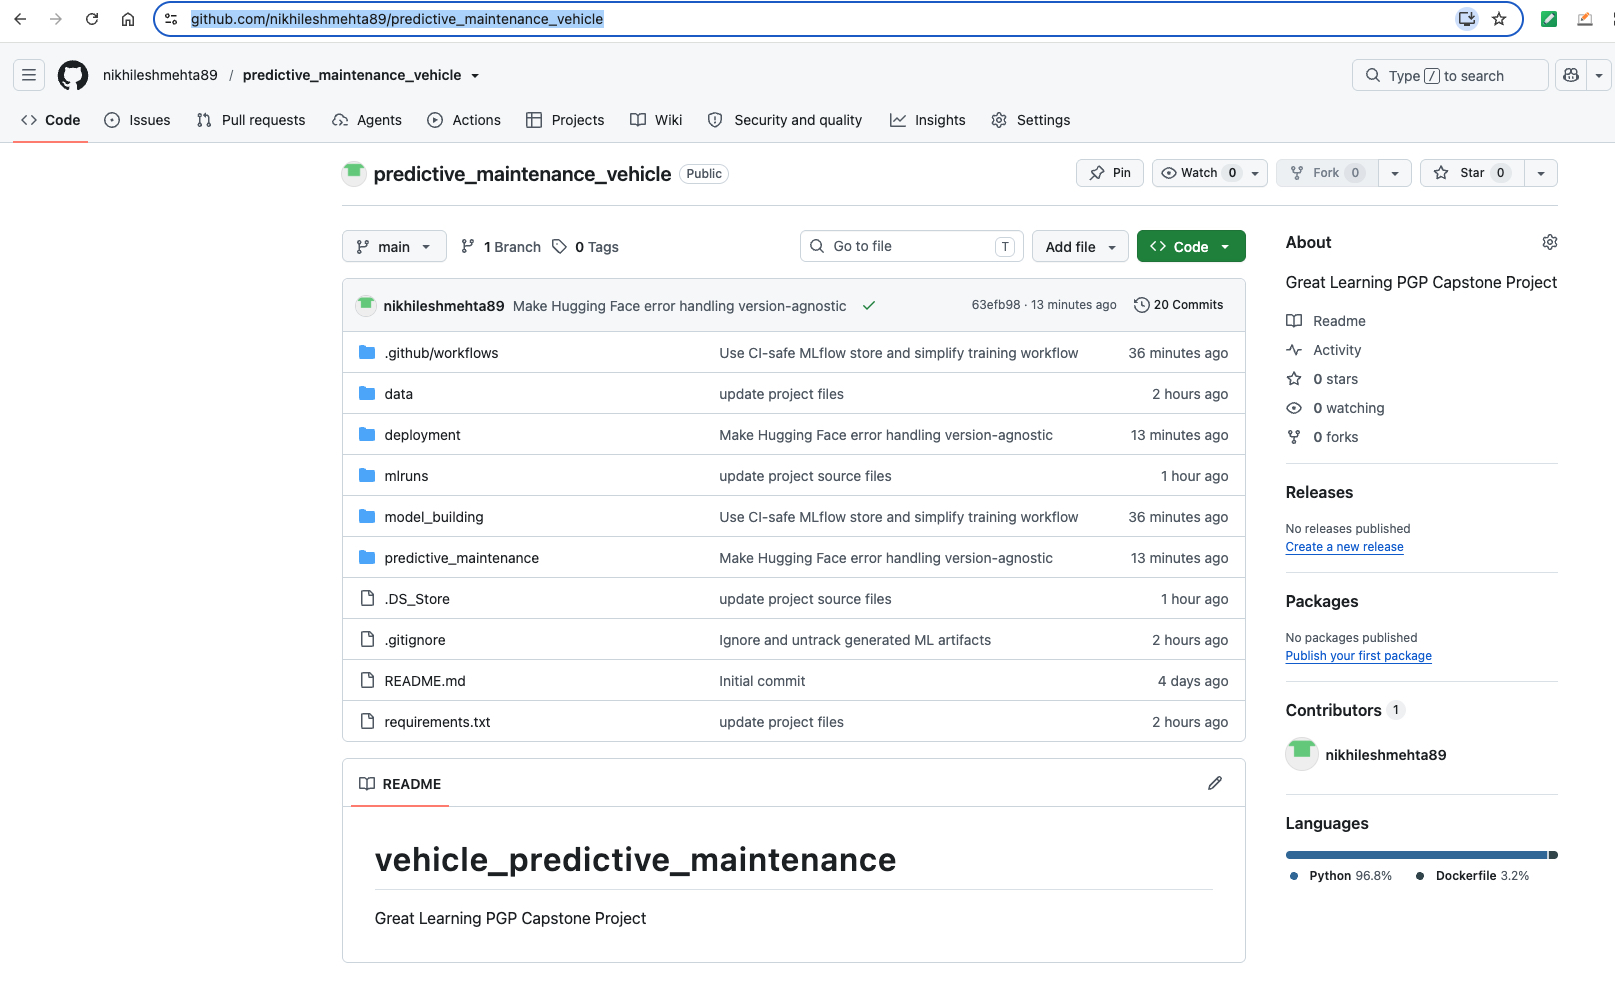

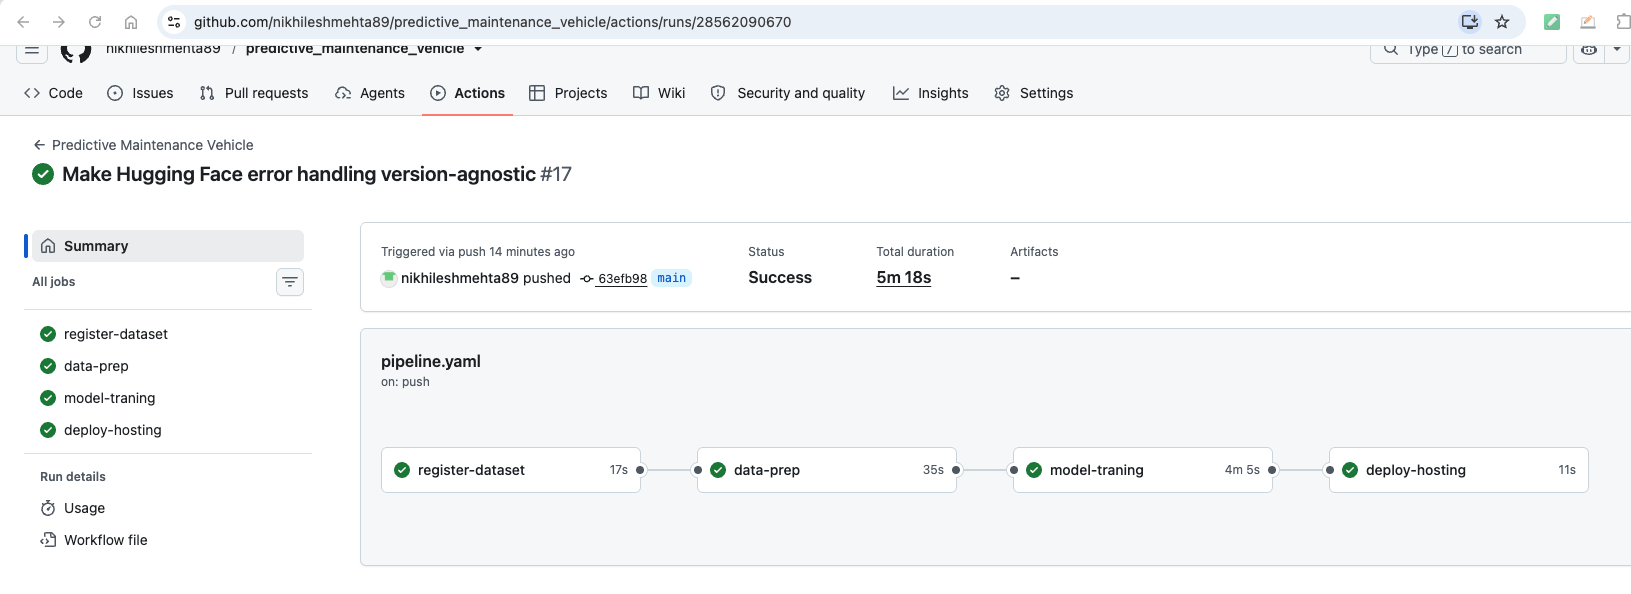

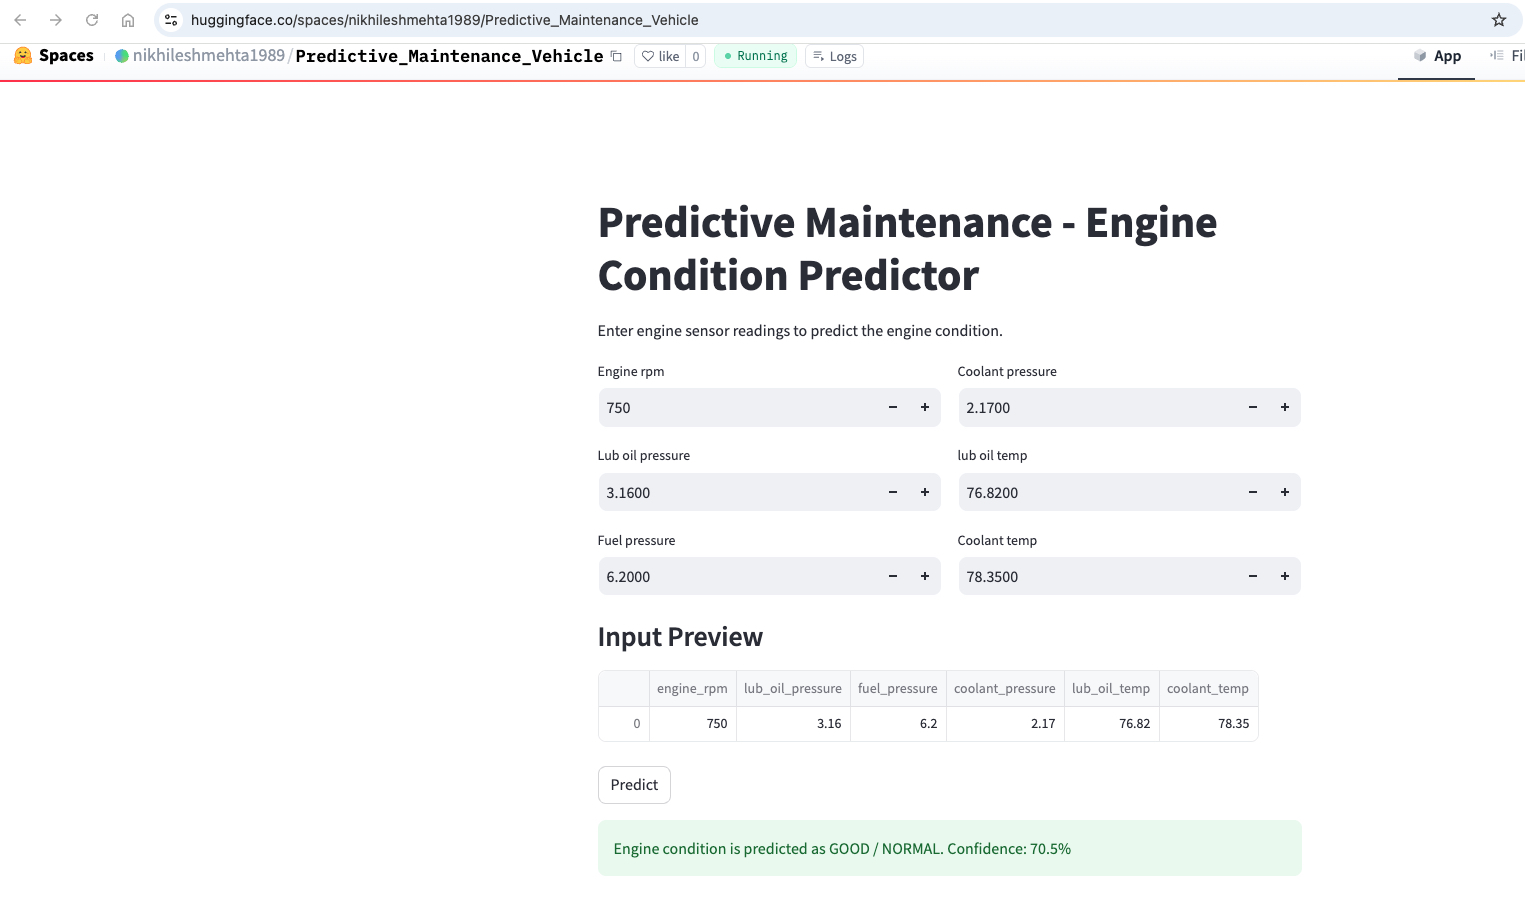

###  Criteria 8
### Actionable Insights and Recommendations
- Key takeaways for the business

#### Business-Ready Actionable Insights

1. Failure risk is detectable early from sensor patterns.
Use the model score as an early-warning signal to identify engines likely to require maintenance before a breakdown occurs.

2. Prioritize maintenance by risk tier instead of fixed schedules.
Create three operational tiers:
- High risk: inspect within 24 hours
- Medium risk: inspect in 3-7 days
- Low risk: continue routine monitoring

3. Lubrication and pressure variables are critical levers.
Patterns in Lub oil pressure, Fuel pressure, and Coolant pressure are strong contributors to classification outcomes, so these should be monitored with tighter operational limits.

4. Data quality directly impacts prediction reliability.
Standardize sensor calibration and logging frequency across all equipment to reduce noisy readings and improve model consistency.

#### Recommendations for Implementation

1. Deploy a live risk dashboard for maintenance planners.
Show per-engine risk class, confidence score, last reading time, and recommended action window.

2. Integrate model alerts into maintenance workflow.
Automatically create a maintenance ticket when predicted risk exceeds the chosen threshold.

3. Tune decision thresholds based on business cost.
Set thresholds to minimize total cost, balancing:
- False negatives (missed failures, high downtime cost)
- False positives (unnecessary inspections, labor cost)

4. Start with a pilot and scale in phases.
Run a 6-8 week pilot on a subset of engines, compare outcomes with historical maintenance, and then expand plant-wide.

5. Retrain on a fixed cadence and monitor drift.
Retrain monthly or quarterly, and trigger early retraining if feature distributions shift materially.


These recommendations convert model output into operational decisions, measurable savings, and a repeatable maintenance strategy.